In [1]:
# pip install libraries
!pip install scikit-posthocs
!pip install timm

In [2]:
#Import libraries
import os
import pandas as pd
import shutil
import numpy as np
import cv2
import torch
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import random_split, DataLoader
from torchvision import transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset
import torch.nn as nn
import torchvision.models as models
import timm
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import random
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm

In [ ]:
# #adding real number of cracked fruits to each smaple (12 trees)
# # puting real cracking number near lables for fuzzy
# # Parent directory with all subfolders
# parent_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_E_SEF_LDA"

# # New parent directory for output
# output_parent_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_E_SEF_LDA_COUNT"

# # mapping of cracked counts
# mapping = {
#     "1": 5,
#     "2":1,
#     "3": 2,
#     "4": 4,
#     "5": 4,
#     "6": 2,
#     "7": 6,
#     "8": 5,
#     "9": 1,
#     "10": 2,
#     "11": 0,
#     "12": 6
# }

# os.makedirs(output_parent_dir, exist_ok=True)

# # Loop over all folders
# for folder in os.listdir(parent_dir):
#     folder_path = os.path.join(parent_dir, folder)
#     if not os.path.isdir(folder_path):
#         continue

#     # Extract the prefix before the first '_'
#     prefix = folder.split("_")[0]

#     # Determine cracked count
#     cracked_count = mapping.get(prefix, None)

#     if cracked_count is None:
#         print(f"Skipping folder '{folder}' (prefix '{prefix}' has no mapping)")
#         continue

#     # Create output folder
#     output_folder_path = os.path.join(output_parent_dir, folder)
#     os.makedirs(output_folder_path, exist_ok=True)

#     # Loop over CSV files in this folder
#     for file in os.listdir(folder_path):
#         if not file.lower().endswith(".csv"):
#             continue

#         file_path = os.path.join(folder_path, file)

#         # Load CSV
#         df = pd.read_csv(file_path)

#         # Add cracked count column
#         df["CrackedFruits"] = cracked_count

#         # Save to output folder
#         output_file_path = os.path.join(output_folder_path, file)
#         df.to_csv(output_file_path, index=False)

#         print(f"Processed and saved: {output_file_path}")

# print("\n All files processed and saved to the new parent folder!")


In [ ]:
#creating Inverse Distance fuzzy labels
# # Your parent folder with all subfolders
# parent_dir = r"/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_COUNT"

# # Output parent folder
# output_parent_dir = r"/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_FUZZY"

# # Create output directory
# os.makedirs(output_parent_dir, exist_ok=True)

# # Class medians
# class_medians = {
#     0: 1,
#     1: 4,
#     2: 8
# }

# # Function to compute fuzzy label vector
# def compute_fuzzy_vector(value, medians):
#     distances = {k: abs(value - v) for k, v in medians.items()}
#     similarities = {k: 1 / (d + 1e-6) for k, d in distances.items()}
#     total = sum(similarities.values())
#     vector = [similarities[k]/total for k in sorted(medians.keys())]
#     return vector

# # Loop over all folders
# for folder in os.listdir(parent_dir):
#     folder_path = os.path.join(parent_dir, folder)
#     if not os.path.isdir(folder_path):
#         continue

#     # Create matching output folder
#     output_folder = os.path.join(output_parent_dir, folder)
#     os.makedirs(output_folder, exist_ok=True)

#     # Loop over CSV files
#     for file in os.listdir(folder_path):
#         if not file.lower().endswith(".csv"):
#             continue

#         file_path = os.path.join(folder_path, file)
#         df = pd.read_csv(file_path)

#         # Make sure you have CrackedFruits column
#         if "CrackedFruits" not in df.columns:
#             print(f"  Skipping {file_path}: No 'CrackedFruits' column")
#             continue

#         # Compute fuzzy labels
#         fuzzy_vectors = df["CrackedFruits"].apply(lambda x: compute_fuzzy_vector(x, class_medians))
#         fuzzy_cols = pd.DataFrame(fuzzy_vectors.tolist(), columns=["Fuzzy_C0", "Fuzzy_C1", "Fuzzy_C2"])

#         # Concatenate back to original DataFrame
#         df = pd.concat([df, fuzzy_cols], axis=1)

#         # Drop CrackedFruits and Label columns if present
#         drop_cols = [col for col in ["CrackedFruits", "Label"] if col in df.columns]
#         df = df.drop(columns=drop_cols)

#         # Save to output folder
#         output_file = os.path.join(output_folder, file)
#         df.to_csv(output_file, index=False)
#         print(f" Processed and saved: {output_file}")

# print("\n All files processed successfully!")


In [ ]:
#creating Triangular fuzzy labels
# # Your parent folder with all subfolders
# parent_dir = r"/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_COUNT"

# # Output parent folder
# output_parent_dir = r"/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_FUZZY_TRIANGLE"

# # Create output directory
# os.makedirs(output_parent_dir, exist_ok=True)

# # Triangle centers for each class
# class_centers = {
#     0: 1,   # Center of Class 0
#     1: 4,   # Center of Class 1
#     2: 8    # Center of Class 2
# }

# # Triangle width (controls how "wide" the triangle is)
# width = 3.5  # Feel free to adjust this parameter

# # Function to compute triangular membership
# def compute_triangle_membership(x, c, w):
#     distance = abs(x - c)
#     membership = max(0.0, 1 - (distance / w))
#     return membership

# # Function to compute fuzzy label vector for a value
# def compute_fuzzy_vector(value, centers, w):
#     memberships = {k: compute_triangle_membership(value, v, w) for k, v in centers.items()}
#     total = sum(memberships.values())
#     # Avoid division by zero (if all memberships are 0)
#     if total == 0:
#         vector = [0.0 for _ in centers]
#     else:
#         vector = [memberships[k] / total for k in sorted(centers.keys())]
#     return vector

# # Loop over all folders
# for folder in os.listdir(parent_dir):
#     folder_path = os.path.join(parent_dir, folder)
#     if not os.path.isdir(folder_path):
#         continue

#     # Create matching output folder
#     output_folder = os.path.join(output_parent_dir, folder)
#     os.makedirs(output_folder, exist_ok=True)

#     # Loop over CSV files
#     for file in os.listdir(folder_path):
#         if not file.lower().endswith(".csv"):
#             continue

#         file_path = os.path.join(folder_path, file)
#         df = pd.read_csv(file_path)

#         # Make sure you have CrackedFruits column
#         if "CrackedFruits" not in df.columns:
#             print(f"  Skipping {file_path}: No 'CrackedFruits' column")
#             continue

#         # Compute fuzzy labels
#         fuzzy_vectors = df["CrackedFruits"].apply(lambda x: compute_fuzzy_vector(x, class_centers, width))
#         fuzzy_cols = pd.DataFrame(fuzzy_vectors.tolist(), columns=["Fuzzy_C0", "Fuzzy_C1", "Fuzzy_C2"])

#         # Concatenate back to original DataFrame
#         df = pd.concat([df, fuzzy_cols], axis=1)

#         # Drop CrackedFruits and Label columns if present
#         drop_cols = [col for col in ["CrackedFruits", "Label"] if col in df.columns]
#         df = df.drop(columns=drop_cols)

#         # Save to output folder
#         output_file = os.path.join(output_folder, file)
#         df.to_csv(output_file, index=False)
#         print(f"Processed and saved: {output_file}")

# print("\nAll files processed successfully!")


In [ ]:
# #creating Gaussian fuzzy labels
# # Your parent folder with all subfolders
# parent_dir = r"/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_E_SEF_LDA_COUNT"

# # Output parent folder
# output_parent_dir = r"/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_E_SEF_LDA_FUZZY_GAUSSIAN"

# # Create output directory
# os.makedirs(output_parent_dir, exist_ok=True)

# # Class medians (centers)
# class_medians = {
#     0: 1,
#     1: 4,
#     2: 8
# }

# # Gaussian width (sigma)
# sigma = 2.0

# # Function to compute fuzzy label vector (Gaussian)
# def compute_fuzzy_vector(value, medians, sigma):
#     similarities = {}
#     for k, center in medians.items():
#         dist_sq = (value - center) ** 2
#         sim = np.exp(-dist_sq / (2 * sigma**2))
#         similarities[k] = sim
#     total = sum(similarities.values())
#     vector = [similarities[k]/total for k in sorted(medians.keys())]
#     return vector

# # Loop over all folders
# for folder in os.listdir(parent_dir):
#     folder_path = os.path.join(parent_dir, folder)
#     if not os.path.isdir(folder_path):
#         continue

#     # Create matching output folder
#     output_folder = os.path.join(output_parent_dir, folder)
#     os.makedirs(output_folder, exist_ok=True)

#     # Loop over CSV files
#     for file in os.listdir(folder_path):
#         if not file.lower().endswith(".csv"):
#             continue

#         file_path = os.path.join(folder_path, file)
#         df = pd.read_csv(file_path)

#         # Make sure you have CrackedFruits column
#         if "CrackedFruits" not in df.columns:
#             print(f"  Skipping {file_path}: No 'CrackedFruits' column")
#             continue

#         # Compute fuzzy labels
#         fuzzy_vectors = df["CrackedFruits"].apply(
#             lambda x: compute_fuzzy_vector(x, class_medians, sigma)
#         )
#         fuzzy_cols = pd.DataFrame(
#             fuzzy_vectors.tolist(), columns=["Fuzzy_C0", "Fuzzy_C1", "Fuzzy_C2"]
#         )

#         # Concatenate back to original DataFrame
#         df = pd.concat([df, fuzzy_cols], axis=1)

#         # Drop CrackedFruits and Label columns if present
#         drop_cols = [col for col in ["CrackedFruits", "Label"] if col in df.columns]
#         df = df.drop(columns=drop_cols)

#         # Save to output folder
#         output_file = os.path.join(output_folder, file)
#         df.to_csv(output_file, index=False)
#         print(f" Processed and saved: {output_file}")

# print("\n All files processed successfully!")


In [7]:
#Data Loader
class CLAHEandEDGE:
    def __init__(self, clip_limit=9.0, grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)

    def __call__(self, pil_img):
        img = np.array(pil_img.convert("L"))                      # Convert to grayscale
        clahe_img = self.clahe.apply(img)                         # Apply CLAHE
        blurred = cv2.GaussianBlur(clahe_img, (1, 1), 0)          # Gaussian blur
        laplacian = cv2.Laplacian(blurred, cv2.CV_8U, ksize=1)    # Laplacian edge
        laplacian = cv2.convertScaleAbs(laplacian)                # Convert to 8-bit
        laplacian = cv2.bitwise_not(laplacian)                    # Invert edges

        resized = cv2.resize(laplacian, (224, 224))               # Resize to 224x224
        normalized = resized.astype(np.float32) / 255.0           # Normalize to [0,1]
        normalized = (normalized - 0.5) / 0.5                      # Normalize to mean=0.5, std=0.5

        return torch.tensor(normalized).unsqueeze(0)              # Shape: (1, 224, 224)
class TripletDatasetByFolder(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform or CLAHEandEDGE()
        self.sample_folders = [
            f for f in os.listdir(folder_path)
            if os.path.isdir(os.path.join(folder_path, f))
        ]

    def __len__(self):
        return len(self.sample_folders)

    def __getitem__(self, idx):
        folder_name = self.sample_folders[idx]
        folder_path = os.path.join(self.folder_path, folder_name)
        weeks = ["week-2.csv", "week-3.csv", "week-4.csv"]

        image_triplet = []
        meta_triplet = []
        fuzzy_label = None

        for i, week_file in enumerate(weeks):
            week_path = os.path.join(folder_path, week_file)
            if not os.path.exists(week_path):
                image_triplet.append(torch.zeros(2, 224, 224))
                meta_triplet.append(torch.zeros(3))
                continue

            df = pd.read_csv(week_path)
            if df.empty or "Image_Path" not in df.columns:
                image_triplet.append(torch.zeros(2, 224, 224))
                meta_triplet.append(torch.zeros(3))
                continue

            try:
                # Load and transform image
                img_path = df.iloc[0]["Image_Path"]
                image = Image.open(img_path).convert("L")
                image = self.transform(image)
                image_triplet.append(image)

                # Extract metadata
                meta = df.drop(columns=["Image_Path", "Image_ID", "Label", "Irrigation"], errors="ignore")
                week_index = float(df["Week"].values[0][-1]) if "Week" in df.columns else (i + 2)
                meta["Week_Index"] = week_index
                meta_numeric = pd.to_numeric(meta.iloc[0], errors="coerce").fillna(0).values.astype("float32")
                meta_tensor = torch.tensor(meta_numeric[:3], dtype=torch.float32)
                meta_triplet.append(meta_tensor)

                # Load fuzzy label for week-4
                if week_file == "week-4.csv":
                    fuzzy_cols = [col for col in df.columns if col.startswith("Fuzzy_C")]
                    if fuzzy_cols:
                        fuzzy_values = df.iloc[0][fuzzy_cols].values.astype(np.float32)
                        fuzzy_label = torch.tensor(fuzzy_values, dtype=torch.float32)

            except Exception as e:
                print(f" Error processing {week_path}: {e}")
                image_triplet.append(torch.zeros(2, 224, 224))
                meta_triplet.append(torch.zeros(3))

        stacked_images = torch.stack(image_triplet)        # (3, 2, H, W)
        stacked_metadata = torch.stack(meta_triplet)       # (3, 3)

        # Safety: if no fuzzy label found, fill zeros
        if fuzzy_label is None:
            fuzzy_label = torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32)

        return stacked_images, stacked_metadata, fuzzy_label


In [ ]:
#Loading north side data
# Image transforms (single channel)
image_transforms = CLAHEandEDGE()

# Directories
train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_FUZZY_GAUSSIAN"
test_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_FUZZY_GAUSSIAN"

# Datasets
full_train_dataset3 = TripletDatasetByFolder(train_row3_dir, transform=image_transforms)
test_row3_dataset = TripletDatasetByFolder(test_row3_dir, transform=image_transforms)

# Split train into 80% train / 20% val
train_size = int(0.8 * len(full_train_dataset3))
val_size = len(full_train_dataset3) - train_size
train_row3_dataset, val_row3_dataset = random_split(full_train_dataset3, [train_size, val_size])

# Loaders
train_loader3 = DataLoader(train_row3_dataset, batch_size=16, shuffle=True)
val_loader3 = DataLoader(val_row3_dataset, batch_size=16, shuffle=True)
test_loader3 = DataLoader(test_row3_dataset, batch_size=16, shuffle=False)

print("Row 3 loaders ready!")
print(f"Train samples: {len(train_row3_dataset)} | Val samples: {len(val_row3_dataset)} | Test samples: {len(test_row3_dataset)}")
print(f"Train size: {len(train_row3_dataset)} | Batch size: {train_loader3.batch_size}")
print(f"Number of batches: {len(train_loader3)}")


Row 3 loaders ready!
Train samples: 980 | Val samples: 245 | Test samples: 321
Train size: 980 | Batch size: 16
Number of batches: 62


In [ ]:
#Loading south side data
# Image transforms
image_transforms = CLAHEandEDGE()

# Directories
train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_FUZZY_GAUSSIAN"
test_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_FUZZY_GAUSSIAN"

# Datasets
full_train_dataset4 = TripletDatasetByFolder(train_row4_dir, transform=image_transforms)
test_row4_dataset = TripletDatasetByFolder(test_row4_dir, transform=image_transforms)

# Split train into 80% train / 20% val
train_size = int(0.8 * len(full_train_dataset4))
val_size = len(full_train_dataset4) - train_size
train_row4_dataset, val_row4_dataset = random_split(full_train_dataset4, [train_size, val_size])

# Loaders
train_loader4 = DataLoader(train_row4_dataset, batch_size=16, shuffle=True)
val_loader4 = DataLoader(val_row4_dataset, batch_size=16, shuffle=False)
test_loader4 = DataLoader(test_row4_dataset, batch_size=16, shuffle=False)

print("Row 4 loaders ready!")
print(f"Train samples: {len(train_row4_dataset)} | Val samples: {len(val_row4_dataset)} | Test samples: {len(test_row4_dataset)}")
print(f"Train size: {len(train_row4_dataset)} | Batch size: {train_loader4.batch_size}")
print(f"Number of batches: {len(train_loader4)}")

Row 4 loaders ready!
Train samples: 980 | Val samples: 245 | Test samples: 321
Train size: 980 | Batch size: 16
Number of batches: 62


In [8]:
#Loading combine north and south side data
# Image transforms
image_transforms = CLAHEandEDGE()

# Directories
train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_FUZZY_GAUSSIAN"
train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_FUZZY_GAUSSIAN"
test_row3_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_FUZZY_GAUSSIAN"
test_row4_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_FUZZY_GAUSSIAN"

# Datasets
train_dataset3 = TripletDatasetByFolder(train_row3_dir, transform=image_transforms)
train_dataset4 = TripletDatasetByFolder(train_row4_dir, transform=image_transforms)
test_dataset3  = TripletDatasetByFolder(test_row3_dir,  transform=image_transforms)
test_dataset4  = TripletDatasetByFolder(test_row4_dir,  transform=image_transforms)

# Combine
combined_train_dataset = ConcatDataset([train_dataset3, train_dataset4])
combined_test_dataset  = ConcatDataset([test_dataset3, test_dataset4])

# Split train into 80% train / 20% val
train_size = int(0.8 * len(combined_train_dataset))
val_size = len(combined_train_dataset) - train_size
train_dataset5, val_dataset5 = random_split(combined_train_dataset, [train_size, val_size])

# DataLoaders
train_loader5 = DataLoader(train_dataset5, batch_size=8, shuffle=True)
val_loader5   = DataLoader(val_dataset5, batch_size=8, shuffle=True)
test_loader5  = DataLoader(combined_test_dataset, batch_size=8, shuffle=False)

print("Combined Row 3 + Row 4 DataLoaders ready!")
print(f"Train samples: {len(train_dataset5)} | Val samples: {len(val_dataset5)} | Test samples: {len(combined_test_dataset)}")


Combined Row 3 + Row 4 DataLoaders ready!
Train samples: 1960 | Val samples: 490 | Test samples: 642


In [9]:
#Load combine north and south side data
# Image transforms
image_transforms =  CLAHEandEDGE()

# Directories 2024
train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_FUZZY_GAUSSIAN"
train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_FUZZY_GAUSSIAN"
test_row3_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_FUZZY_GAUSSIAN"
test_row4_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_FUZZY_GAUSSIAN"
# Directories 2025
train_W_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_W_SEF_LDA_FUZZY_GAUSSIAN"
train_E_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_E_SEF_LDA_FUZZY_GAUSSIAN"
test_W_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_W_SEF_LDA_FUZZY_GAUSSIAN"
test_E_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_E_SEF_LDA_FUZZY_GAUSSIAN"

# Datasets 2024
train_dataset3 = TripletDatasetByFolder(train_row3_dir, transform=image_transforms)
train_dataset4 = TripletDatasetByFolder(train_row4_dir, transform=image_transforms)
test_dataset3  = TripletDatasetByFolder(test_row3_dir,  transform=image_transforms)
test_dataset4  = TripletDatasetByFolder(test_row4_dir,  transform=image_transforms)

# Datasets 2025
train_datasetW = TripletDatasetByFolder(train_W_dir, transform=image_transforms)
train_datasetE = TripletDatasetByFolder(train_E_dir, transform=image_transforms)
test_datasetW  = TripletDatasetByFolder(test_W_dir,  transform=image_transforms)
test_datasetE  = TripletDatasetByFolder(test_E_dir,  transform=image_transforms)


# Combine 2024,2024
combined_train_dataset = ConcatDataset([train_dataset3, train_dataset4, test_dataset3, test_dataset4])
combined_test_dataset  = ConcatDataset([train_datasetW, train_datasetE, test_datasetW, test_datasetE])

# Split train into 80% train / 20% val
train_size = int(0.8 * len(combined_train_dataset))
val_size = len(combined_train_dataset) - train_size
train_dataset6, val_dataset6 = random_split(combined_train_dataset, [train_size, val_size])

# DataLoaders
train_loader6 = DataLoader(train_dataset6, batch_size=8, shuffle=True)
val_loader6   = DataLoader(val_dataset6, batch_size=8, shuffle=True)
test_loader6  = DataLoader(combined_test_dataset, batch_size=8, shuffle=False)

print("Combined Row 3 + Row 4 DataLoaders ready!")
print(f"Train samples: {len(train_dataset6)} | Val samples: {len(val_dataset6)} | Test samples: {len(combined_test_dataset)}")


Combined Row 3 + Row 4 DataLoaders ready!
Train samples: 2473 | Val samples: 619 | Test samples: 1008


In [ ]:
# LSTM Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        # lstm_out: (B, T, H)
        attn_weights = self.attn(lstm_out)         # (B, T, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)  # Normalize across time
        context = (lstm_out * attn_weights).sum(dim=1)     # Weighted sum: (B, H)
        return context

In [ ]:
# CNN Attention Block
class TemporalImageAttention(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128):
        super().__init__()
        self.attn_mlp = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # x: (B, T, D) where T = 3 time steps (weeks), D = CNN feature dim (2048)
        scores = self.attn_mlp(x)                      # (B, T, 1)
        weights = torch.softmax(scores, dim=1)         # (B, T, 1)
        context = (x * weights).sum(dim=1)             # (B, D)
        return context

In [ ]:
# PomRowModel with timm ConvNeXt
class PomRowModel(nn.Module):
    def __init__(self, num_metadata_features, hidden_dim=128, lstm_layers=3, num_classes=3):
        super().__init__()

        # ConvNeXt from timm
        self.cnn = timm.create_model('convnext_base', pretrained=True, num_classes=0)  # No FC layer
        cnn_output_dim = self.cnn.num_features  # Should be 1024 for convnext_base

        # Modify the first convolutional layer to accept 1 channel
        self.cnn.stem[0] = nn.Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))

        # LSTM for Metadata
        self.lstm = nn.LSTM(input_size=num_metadata_features,
                            hidden_size=hidden_dim,
                            num_layers=lstm_layers,
                            batch_first=True)

        # Dual Attention
        self.meta_attention = AttentionBlock(hidden_dim)
        self.img_attention = TemporalImageAttention(cnn_output_dim)

        # Fully Connected Head
        self.fc = nn.Sequential(
            nn.Linear(cnn_output_dim + hidden_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, meta):
        # imgs: (B, 3, C, H, W), meta: (B, 3, D)
        B, T, C, H, W = imgs.shape
        imgs = imgs.view(B * T, C, H, W)  # (B*T, C, H, W)
        cnn_feats = self.cnn(imgs)        # (B*T, F)
        cnn_feats = cnn_feats.view(B, T, -1)  # (B, 3, F)
        img_attn = self.img_attention(cnn_feats)  # (B, F)

        lstm_out, _ = self.lstm(meta)          # (B, 3, H)
        meta_attn = self.meta_attention(lstm_out)  # (B, H)

        combined = torch.cat([img_attn, meta_attn], dim=1)  # (B, F + H)
        return self.fc(combined)

In [ ]:
#Traning Loop with MSE loss
GPU = 0
SEED = 2023

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.cuda.manual_seed_all(SEED)

device = torch.device(f"cuda:{GPU}" if torch.cuda.is_available() else "cpu")


def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, metadata, fuzzy_labels in val_loader:
            images = images.to(device)
            metadata = metadata.to(device)
            fuzzy_labels = fuzzy_labels.to(device).float()

            outputs = model(images, metadata)
            loss = criterion(outputs, fuzzy_labels)
            val_loss += loss.item()

    return val_loss / len(val_loader)


def train_model(model, dataloader, val_loader, num_epochs=10, lr=0.0003):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        print(f"\n Epoch {epoch+1}/{num_epochs}")

        for i, (images, metadata, fuzzy_labels) in enumerate(dataloader):
            images = images.to(device)
            metadata = metadata.to(device)
            fuzzy_labels = fuzzy_labels.to(device).float()

            optimizer.zero_grad()
            outputs = model(images, metadata)
            loss = criterion(outputs, fuzzy_labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(dataloader)
        print(f" Epoch {epoch+1} Avg Train Loss: {avg_train_loss:.4f}")

        val_loss = validate(model, val_loader, criterion, device)
        print(f" Validation Loss: {val_loss:.4f}")
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = model.state_dict()
            print(f" New best model saved (val_loss = {val_loss:.4f})")

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(" Loaded best model weights from memory!")

    print(" Training complete!")
    return model

In [ ]:
#Traning Model
# Set number of metadata features
num_metadata_features = 3

# Initialize model
model = PomRowModel(num_metadata_features=num_metadata_features)

# Train the model
train_model(model, train_loader6, val_loader6, num_epochs=30, lr=0.0001)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/354M [00:00<?, ?B/s]


 Epoch 1/30
 Epoch 1 Avg Train Loss: 0.0810
 Validation Loss: 0.0547
 New best model saved (val_loss = 0.0547)

 Epoch 2/30
 Epoch 2 Avg Train Loss: 0.0571
 Validation Loss: 0.0511
 New best model saved (val_loss = 0.0511)

 Epoch 3/30
 Epoch 3 Avg Train Loss: 0.0562
 Validation Loss: 0.0489
 New best model saved (val_loss = 0.0489)

 Epoch 4/30
 Epoch 4 Avg Train Loss: 0.0551
 Validation Loss: 0.0516

 Epoch 5/30
 Epoch 5 Avg Train Loss: 0.0542
 Validation Loss: 0.0475
 New best model saved (val_loss = 0.0475)

 Epoch 6/30
 Epoch 6 Avg Train Loss: 0.0532
 Validation Loss: 0.0466
 New best model saved (val_loss = 0.0466)

 Epoch 7/30
 Epoch 7 Avg Train Loss: 0.0520
 Validation Loss: 0.0469

 Epoch 8/30
 Epoch 8 Avg Train Loss: 0.0499
 Validation Loss: 0.0439
 New best model saved (val_loss = 0.0439)

 Epoch 9/30
 Epoch 9 Avg Train Loss: 0.0489
 Validation Loss: 0.0440

 Epoch 10/30
 Epoch 10 Avg Train Loss: 0.0482
 Validation Loss: 0.0436
 New best model saved (val_loss = 0.0436)

 Ep

PomRowModel(
  (cnn): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
            (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=128, out_features=512, bias=True)
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Linear(in_features=512, out_features=128, bias=True)
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw):

In [ ]:
#model Evluation loop
def test_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for image_seq, metadata_seq, fuzzy_labels in test_loader:
            image_seq = image_seq.to(device)           # (B, 3, C, H, W)
            metadata_seq = metadata_seq.to(device)     # (B, 3, D)
            fuzzy_labels = fuzzy_labels.to(device)     # (B, num_classes)

            outputs = model(image_seq, metadata_seq)   # (B, num_classes)

            # If your model does NOT include Softmax, uncomment this:
            # outputs = torch.softmax(outputs, dim=1)

            # Predicted class index: argmax
            preds = torch.argmax(outputs, dim=1)

            # True class index: argmax of fuzzy label
            true_classes = torch.argmax(fuzzy_labels, dim=1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(true_classes.cpu().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Accuracy
    accuracy = 100 * np.sum(all_preds == all_labels) / len(all_labels)
    print(f"\n Test Accuracy: {accuracy:.2f}%")

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\n Confusion Matrix:")
    print(cm)

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification report
    print("\n Classification Report:")
    print(classification_report(all_labels, all_preds, digits=3))

    return all_preds, all_labels


 Test Accuracy: 46.03%

 Confusion Matrix:
[[338  66 112]
 [262 126 104]
 [  0   0   0]]


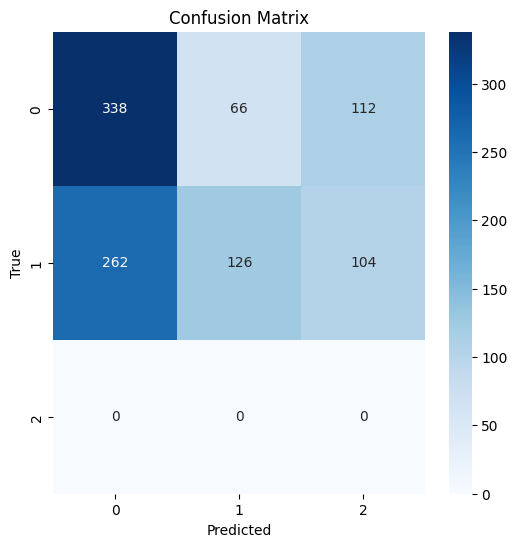


 Classification Report:
              precision    recall  f1-score   support

           0      0.563     0.655     0.606       516
           1      0.656     0.256     0.368       492
           2      0.000     0.000     0.000         0

    accuracy                          0.460      1008
   macro avg      0.407     0.304     0.325      1008
weighted avg      0.609     0.460     0.490      1008



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
#Evaluate model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# test_loader should yield: (image_seq, metadata_seq, labels)
preds, labels = test_model(model, test_loader6, device)

In [ ]:
#Second evaulation Loop
def test_model_fuzzy(model, test_loader, device):
    model.eval()
    mse_losses = []
    ce_losses = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, metadata, fuzzy_targets in test_loader:
            images = images.to(device)
            metadata = metadata.to(device)
            fuzzy_targets = fuzzy_targets.to(device)  # Shape: (B, 3)

            logits = model(images, metadata)         # (B, 3)
            probs = torch.softmax(logits, dim=1)     # (B, 3)

            # MSE Loss per sample
            mse = F.mse_loss(probs, fuzzy_targets, reduction="none").mean(dim=1)  # (B,)
            mse_losses.extend(mse.cpu().numpy())

            # Cross-Entropy Loss (KL divergence)
            ce = -(fuzzy_targets * torch.log(probs + 1e-8)).sum(dim=1)  # (B,)
            ce_losses.extend(ce.cpu().numpy())

            # For "hard" reporting
            pred_classes = torch.argmax(probs, dim=1).cpu().numpy()
            true_classes = torch.argmax(fuzzy_targets, dim=1).cpu().numpy()
            all_preds.extend(pred_classes)
            all_targets.extend(true_classes)

    # Mean losses
    mean_mse = np.mean(mse_losses)
    mean_ce = np.mean(ce_losses)

    print(f"\n Mean MSE (prob vs fuzzy): {mean_mse:.4f}")
    print(f" Mean Cross-Entropy (prob vs fuzzy): {mean_ce:.4f}")

    # Also show hard confusion matrix for reference
    cm = confusion_matrix(all_targets, all_preds)
    print("\n Confusion Matrix (hard labels for reference):")
    print(cm)

    print("\n Classification Report (hard labels for reference):")
    print(classification_report(all_targets, all_preds, digits=3))

    return mean_mse, mean_ce



In [ ]:
#Second model evaluation
test_model_fuzzy(model, test_loader6, device)


 Mean MSE (prob vs fuzzy): 0.0686
 Mean Cross-Entropy (prob vs fuzzy): 1.0920

 Confusion Matrix (hard labels for reference):
[[338  66 112]
 [262 126 104]
 [  0   0   0]]

 Classification Report (hard labels for reference):
              precision    recall  f1-score   support

           0      0.563     0.655     0.606       516
           1      0.656     0.256     0.368       492
           2      0.000     0.000     0.000         0

    accuracy                          0.460      1008
   macro avg      0.407     0.304     0.325      1008
weighted avg      0.609     0.460     0.490      1008



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


(np.float32(0.0685663), np.float32(1.0920125))

In [ ]:
# Save the trained model
model_save_path = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_LSTM_convnext_LADS_8BATCH_FUZZY_GAUSSIAN_LR00001_CL9_GRID8_G1_EDGE1.pth"
torch.save(model.state_dict(), model_save_path)
print(f" Model saved to {model_save_path}")

 Model saved to /content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_LSTM_convnext_LADS_8BATCH_FUZZY_GAUSSIAN_LR00001_CL9_GRID8_G1_EDGE1.pth


In [ ]:
#Load combine north and south side data
# Image transforms
image_transforms =  CLAHEandEDGE()

# Directories
train_W_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_W_SEF_LDA_FUZZY_GAUSSIAN"
test_W_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_W_SEF_LDA_FUZZY_GAUSSIAN"


# Datasets
train_datasetW = TripletDatasetByFolder(train_W_dir, transform=image_transforms)
test_datasetW = TripletDatasetByFolder(test_W_dir,  transform=image_transforms)


# Combine
combined_W = ConcatDataset([train_datasetW, test_datasetW])

W_loader  = DataLoader(combined_W, batch_size=8, shuffle=False)

print("Combined Row 3 + Row 4 DataLoaders ready!")
print(f" samples: {len(combined_W)}")


Combined Row 3 + Row 4 DataLoaders ready!
 samples: 504


In [ ]:
#Load combine north and south side data
# Image transforms
image_transforms =  CLAHEandEDGE()

# Directories
train_E_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_E_SEF_LDA_FUZZY_GAUSSIAN"
test_E_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_E_SEF_LDA_FUZZY_GAUSSIAN"


# Datasets
train_datasetE = TripletDatasetByFolder(train_E_dir, transform=image_transforms)
test_datasetE = TripletDatasetByFolder(test_E_dir,  transform=image_transforms)


# Combine
combined_E = ConcatDataset([train_datasetE, test_datasetE])

E_loader  = DataLoader(combined_E, batch_size=8, shuffle=False)

print("Combined Row 3 + Row 4 DataLoaders ready!")
print(f" samples: {len(combined_E)}")

Combined Row 3 + Row 4 DataLoaders ready!
 samples: 504


In [ ]:
#Inter side MSE eavuate MSE from prediction of north side againts south side of the field metric
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models
row3_model = PomRowModel(num_metadata_features=3).to(device)
row4_model = PomRowModel(num_metadata_features=3).to(device)

row3_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_FUZZY_LSTM_convnext_LADS_8BATCH_CLHAE98_G1_EDGE1_LR00001/2025_LSTM_convnext_LADS_8BATCH_FUZZY_GAUSSIAN_LR00001_CL9_GRID8_G1_EDGE1.pth", map_location=device))
row4_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_FUZZY_LSTM_convnext_LADS_8BATCH_CLHAE98_G1_EDGE1_LR00001/2025_LSTM_convnext_LADS_8BATCH_FUZZY_GAUSSIAN_LR00001_CL9_GRID8_G1_EDGE1.pth", map_location=device))

row3_model.eval()
row4_model.eval()

mse_list = []
cross_entropy_list = []
all_probs_r3 = []
all_probs_r4 = []

for batch_row3, batch_row4 in tqdm(zip(W_loader, E_loader), total=len(W_loader)):
    imgs_r3, meta_r3, _ = batch_row3
    imgs_r4, meta_r4, _ = batch_row4

    imgs_r3 = imgs_r3.to(device)
    meta_r3 = meta_r3.to(device)
    imgs_r4 = imgs_r4.to(device)
    meta_r4 = meta_r4.to(device)

    with torch.no_grad():
        logits_r3 = row3_model(imgs_r3, meta_r3)  # (B, C)
        logits_r4 = row4_model(imgs_r4, meta_r4)

        probs_r3 = torch.softmax(logits_r3, dim=1)  # (B, C)
        probs_r4 = torch.softmax(logits_r4, dim=1)

    # Compute metrics for each sample
    for p3, p4 in zip(probs_r3, probs_r4):
        mse = torch.mean((p3 - p4) ** 2).item()
        ce = -torch.sum(p4 * torch.log(p3 + 1e-8)).item()  # Cross-entropy between p3 and p4

        mse_list.append(mse)
        cross_entropy_list.append(ce)

        all_probs_r3.append(p3.cpu().numpy())
        all_probs_r4.append(p4.cpu().numpy())

# Aggregate metrics
mean_mse = np.mean(mse_list)
mean_ce = np.mean(cross_entropy_list)

print(f"\nMean MSE between Row3 and Row4 outputs: {mean_mse:.4f}")
print(f"Mean Cross-Entropy between Row3 and Row4 outputs: {mean_ce:.4f}")

# Optionally save outputs for inspection
np.save("probs_row3.npy", np.array(all_probs_r3))
np.save("probs_row4.npy", np.array(all_probs_r4))


100%|██████████| 63/63 [00:33<00:00,  1.89it/s]


Mean MSE between Row3 and Row4 outputs: 0.0177
Mean Cross-Entropy between Row3 and Row4 outputs: 1.1392


100%|██████████| 81/81 [00:23<00:00,  3.52it/s]


Mean Cosine Similarity: 0.8962
Predicted max equals fuzzy max: 582/642 (90.65%)


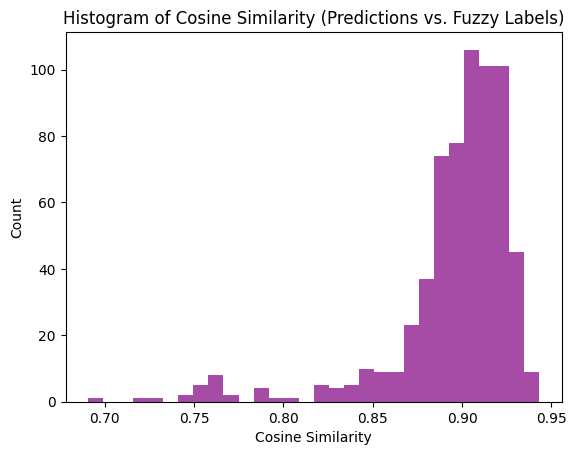

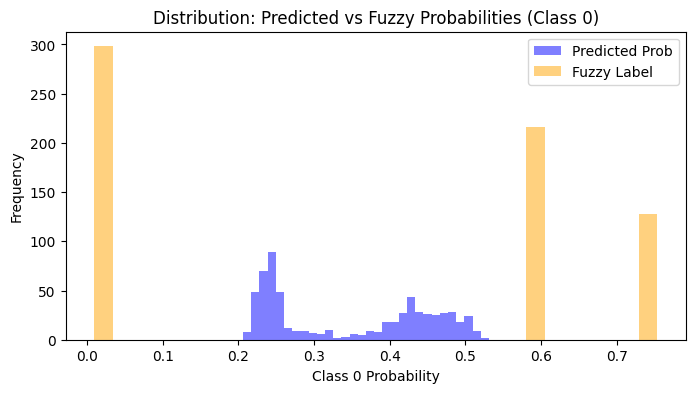

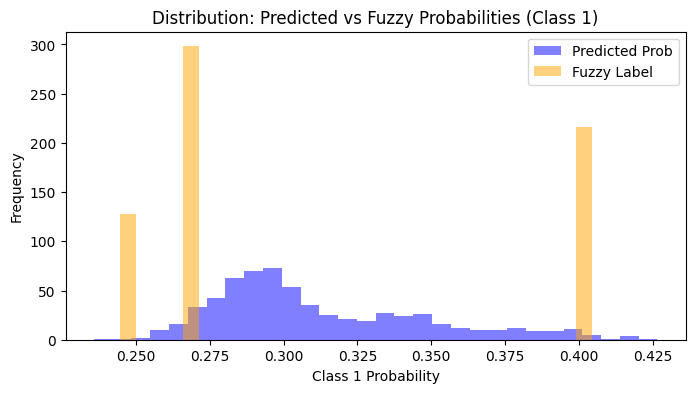

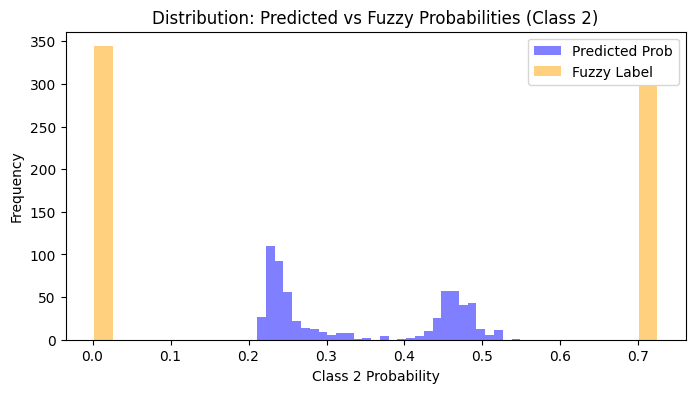

In [ ]:
#Cosine Similarity metric and each class probablity disribuation Visualization
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

cosine_sims = []
max_match_count = 0
total_samples = 0
all_pred_probs = []
all_fuzzy_labels = []

with torch.no_grad():
    for images, metadata, fuzzy_labels in tqdm(test_loader6):
        images = images.to(device)
        metadata = metadata.to(device)
        fuzzy_labels = fuzzy_labels.to(device)

        logits = model(images, metadata)
        probs = F.softmax(logits, dim=1)

        # Save for histogram later
        all_pred_probs.append(probs.cpu())
        all_fuzzy_labels.append(fuzzy_labels.cpu())

        # Cosine similarity per sample
        cos_sim_batch = F.cosine_similarity(probs, fuzzy_labels, dim=1)
        cosine_sims.extend(cos_sim_batch.cpu().numpy())

        # Max agreement
        pred_max = probs.argmax(dim=1)
        fuzzy_max = fuzzy_labels.argmax(dim=1)
        max_match_count += (pred_max == fuzzy_max).sum().item()
        total_samples += probs.size(0)

# Convert to arrays
cosine_sims = np.array(cosine_sims)
all_pred_probs = torch.cat(all_pred_probs, dim=0).numpy()
all_fuzzy_labels = torch.cat(all_fuzzy_labels, dim=0).numpy()

# Results
mean_cos_sim = cosine_sims.mean()
print(f"\nMean Cosine Similarity: {mean_cos_sim:.4f}")
print(f"Predicted max equals fuzzy max: {max_match_count}/{total_samples} ({100 * max_match_count/total_samples:.2f}%)")

# Histogram of cosine similarity
plt.hist(cosine_sims, bins=30, color="purple", alpha=0.7)
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.title("Histogram of Cosine Similarity (Predictions vs. Fuzzy Labels)")
plt.show()

# Histogram per class (predicted probabilities vs fuzzy labels)
num_classes = all_pred_probs.shape[1]
for c in range(num_classes):
    plt.figure(figsize=(8, 4))
    plt.hist(all_pred_probs[:, c], bins=30, alpha=0.5, label="Predicted Prob", color="blue")
    plt.hist(all_fuzzy_labels[:, c], bins=30, alpha=0.5, label="Fuzzy Label", color="orange")
    plt.xlabel(f"Class {c} Probability")
    plt.ylabel("Frequency")
    plt.title(f"Distribution: Predicted vs Fuzzy Probabilities (Class {c})")
    plt.legend()
    plt.show()

✔ Loaded trained model.


100%|██████████| 126/126 [1:24:57<00:00, 40.46s/it]


Mean Cosine Similarity: 0.7918
Predicted max equals fuzzy max: 464/1008 (46.03%)


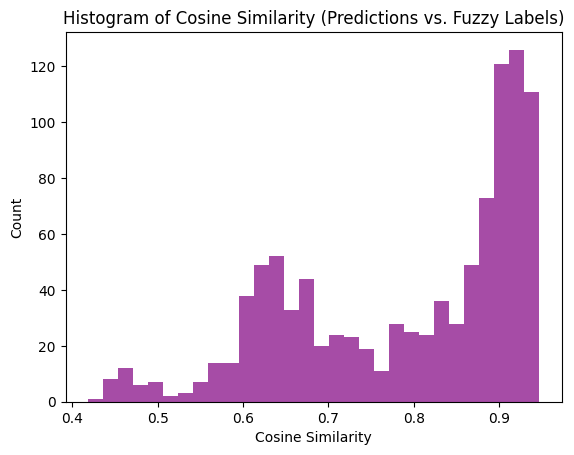

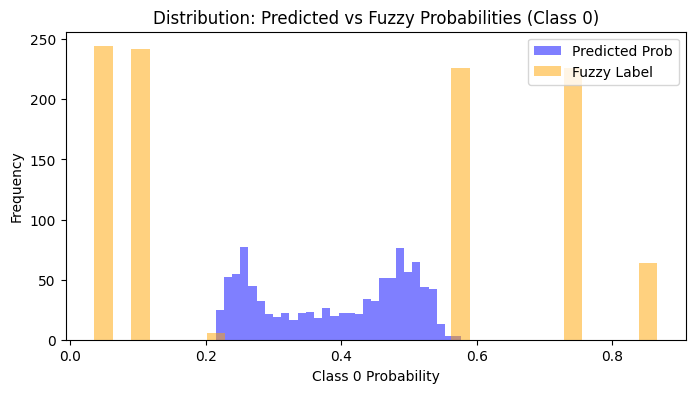

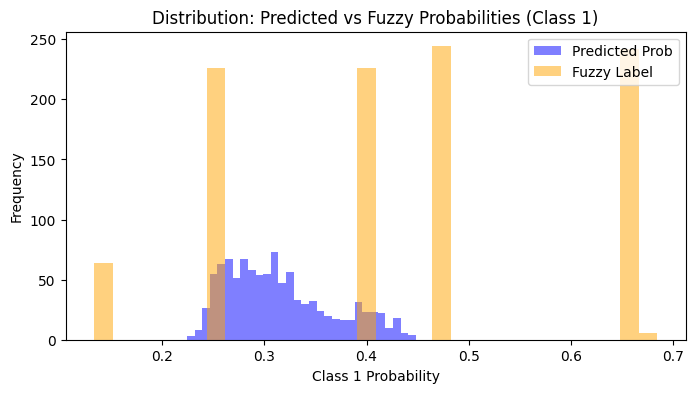

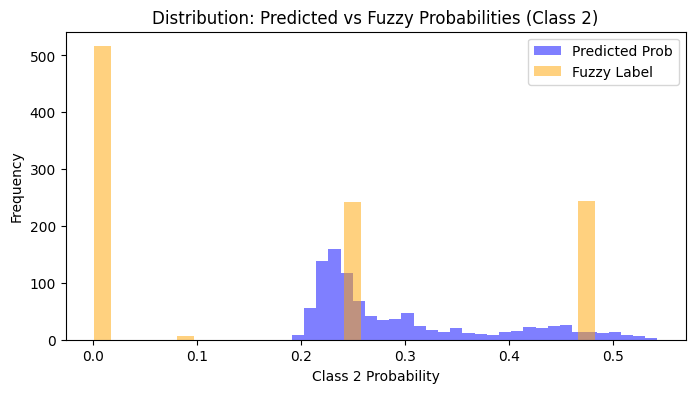

In [10]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn as nn
import timm

# ---------------------------------------------------------
# (1) >>>>>> RECREATE YOUR MODEL CLASS HERE <<<<<<
# ---------------------------------------------------------
# Example:
# from model_file import CitrusRowModel
# model = CitrusRowModel(img_channels=3, meta_input_dim=10, num_classes=3)

# LSTM Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        # lstm_out: (B, T, H)
        attn_weights = self.attn(lstm_out)         # (B, T, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)  # Normalize across time
        context = (lstm_out * attn_weights).sum(dim=1)     # Weighted sum: (B, H)
        return context

# CNN Attention Block
class TemporalImageAttention(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128):
        super().__init__()
        self.attn_mlp = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # x: (B, T, D) where T = 3 time steps (weeks), D = CNN feature dim (2048)
        scores = self.attn_mlp(x)                      # (B, T, 1)
        weights = torch.softmax(scores, dim=1)         # (B, T, 1)
        context = (x * weights).sum(dim=1)             # (B, D)
        return context

# PomRowModel with timm ConvNeXt
class PomRowModel(nn.Module):
    def __init__(self, num_metadata_features, hidden_dim=128, lstm_layers=3, num_classes=3):
        super().__init__()

        # ConvNeXt from timm
        self.cnn = timm.create_model('convnext_base', pretrained=True, num_classes=0)  # No FC layer
        cnn_output_dim = self.cnn.num_features  # Should be 1024 for convnext_base

        # Modify the first convolutional layer to accept 1 channel
        self.cnn.stem[0] = nn.Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))

        # LSTM for Metadata
        self.lstm = nn.LSTM(input_size=num_metadata_features,
                            hidden_size=hidden_dim,
                            num_layers=lstm_layers,
                            batch_first=True)

        # Dual Attention
        self.meta_attention = AttentionBlock(hidden_dim)
        self.img_attention = TemporalImageAttention(cnn_output_dim)

        # Fully Connected Head
        self.fc = nn.Sequential(
            nn.Linear(cnn_output_dim + hidden_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, meta):
        # imgs: (B, 3, C, H, W), meta: (B, 3, D)
        B, T, C, H, W = imgs.shape
        imgs = imgs.view(B * T, C, H, W)  # (B*T, C, H, W)
        cnn_feats = self.cnn(imgs)        # (B*T, F)
        cnn_feats = cnn_feats.view(B, T, -1)  # (B, 3, F)
        img_attn = self.img_attention(cnn_feats)  # (B, F)

        lstm_out, _ = self.lstm(meta)          # (B, 3, H)
        meta_attn = self.meta_attention(lstm_out)  # (B, H)

        combined = torch.cat([img_attn, meta_attn], dim=1)  # (B, F + H)
        return self.fc(combined)

# Set number of metadata features
num_metadata_features = 3

# Initialize model
model = PomRowModel(num_metadata_features=num_metadata_features)


# ---------------------------------------------------------
# (2) >>>>>> LOAD YOUR TRAINED WEIGHTS HERE <<<<<<
# ---------------------------------------------------------
checkpoint_path = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_FUZZY_LSTM_convnext_LADS_8BATCH_CLHAE98_G1_EDGE1_LR00001/2025_LSTM_convnext_LADS_8BATCH_FUZZY_GAUSSIAN_LR00001_CL9_GRID8_G1_EDGE1.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

print("✔ Loaded trained model.")
model.eval()

# ---------------------------------------------------------
# COSINE SIMILARITY EVALUATION
# ---------------------------------------------------------

cosine_sims = []
max_match_count = 0
total_samples = 0
all_pred_probs = []
all_fuzzy_labels = []

with torch.no_grad():
    for images, metadata, fuzzy_labels in tqdm(test_loader6):

        images = images.to(device)
        metadata = metadata.to(device)
        fuzzy_labels = fuzzy_labels.to(device)

        logits = model(images, metadata)
        probs = F.softmax(logits, dim=1)

        # Save for histogram
        all_pred_probs.append(probs.cpu())
        all_fuzzy_labels.append(fuzzy_labels.cpu())

        # Cosine similarity per sample
        cos_sim_batch = F.cosine_similarity(probs, fuzzy_labels, dim=1)
        cosine_sims.extend(cos_sim_batch.cpu().numpy())

        # Max-probability agreement
        pred_max = probs.argmax(dim=1)
        fuzzy_max = fuzzy_labels.argmax(dim=1)
        max_match_count += (pred_max == fuzzy_max).sum().item()
        total_samples += probs.size(0)

# Convert to arrays
cosine_sims = np.array(cosine_sims)
all_pred_probs = torch.cat(all_pred_probs, dim=0).numpy()
all_fuzzy_labels = torch.cat(all_fuzzy_labels, dim=0).numpy()

# Results
mean_cos_sim = cosine_sims.mean()
print(f"\nMean Cosine Similarity: {mean_cos_sim:.4f}")
print(f"Predicted max equals fuzzy max: {max_match_count}/{total_samples} ({100 * max_match_count/total_samples:.2f}%)")

# Histogram of cosine similarity
plt.hist(cosine_sims, bins=30, color="purple", alpha=0.7)
plt.xlabel("Cosine Similarity")
plt.ylabel("Count")
plt.title("Histogram of Cosine Similarity (Predictions vs. Fuzzy Labels)")
plt.show()

# Histogram per class (predicted probabilities vs fuzzy labels)
num_classes = all_pred_probs.shape[1]
for c in range(num_classes):
    plt.figure(figsize=(8, 4))
    plt.hist(all_pred_probs[:, c], bins=30, alpha=0.5, label="Predicted Prob", color="blue")
    plt.hist(all_fuzzy_labels[:, c], bins=30, alpha=0.5, label="Fuzzy Label", color="orange")
    plt.xlabel(f"Class {c} Probability")
    plt.ylabel("Frequency")
    plt.title(f"Distribution: Predicted vs Fuzzy Probabilities (Class {c})")
    plt.legend()
    plt.show()